- Import required libraries

In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

- Import dataset

In [2]:
df = pd.read_csv('customer_behavior_acquisition.csv', parse_dates=['signup_date', 'event_timestamp'])
df = df.drop(columns=['key'])
df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp
119995,1552,181,Amazon Fire TV,Smart TV,Samsung,US,EMEA,2024-11-08,billing,2425,8.93,Success,2024-07-04 19:38:26.819164
119996,4394,152,PS5,Set Top Box,Google,VN,Americas,2025-05-26,billing,1858,13.07,Failed,2025-07-31 08:02:36.006365
119997,4410,172,iPad,Set Top Box,Apple,CA,Americas,2024-11-04,signup,2999,14.79,Failed,2025-02-28 21:36:52.395120
119998,1082,169,iPad,Set Top Box,Amazon,CA,APAC,2024-07-06,signup,3823,2.54,Failed,2025-02-11 21:39:01.224203
119999,1832,242,PS5,Smart TV,Apple,FR,Americas,2025-09-01,playback,2734,13.31,Failed,2026-03-18 23:53:18.511336


- Keep only retention event

In [3]:
df = df[(df['event_type'] == 'billing') & (df['payment_status']== 'Success')].copy()
df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp
119989,2722,410,Amazon Fire TV,Streaming Stick,Apple,FR,APAC,2025-03-21,billing,1839,4.51,Success,2024-09-06 20:16:20.062171
119991,3927,437,PS5,Game Console,Google,CA,EMEA,2025-06-21,billing,1199,5.80,Success,2024-06-23 19:49:18.419641
119993,2210,134,iPad,Smart TV,Google,ES,EMEA,2024-10-03,billing,1104,9.66,Success,2026-01-13 19:25:43.430291
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062
119995,1552,181,Amazon Fire TV,Smart TV,Samsung,US,EMEA,2024-11-08,billing,2425,8.93,Success,2024-07-04 19:38:26.819164


In [4]:
df.dtypes

member_id                   int64
device_id                   int64
device_name                object
device_category            object
partner_name               object
country                    object
region                     object
signup_date        datetime64[ns]
event_type                 object
watch_time                  int64
amount                    float64
payment_status             object
event_timestamp    datetime64[ns]
dtype: object

- Create a cohort group for each customer based on their first purchase date
- Transform the event_timestamp to extract the month period

In [ ]:
df['first_event'] = (
    df.groupby('member_id')['event_timestamp']
    .transform('min')
)


df['cohort_first_month'] = (
    df.groupby('member_id')['event_timestamp']
    .transform('min')
    .dt.to_period('M')
)
df['event_month'] = df['event_timestamp'].dt.to_period('M')
df.tail()

,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,cohort_first_month,event_month
119989,2722,410,Amazon Fire TV,Streaming Stick,Apple,FR,APAC,2025-03-21,billing,1839,4.51,Success,2024-09-06 20:16:20.062171,2024-09,2024-09
119991,3927,437,PS5,Game Console,Google,CA,EMEA,2025-06-21,billing,1199,5.80,Success,2024-06-23 19:49:18.419641,2024-05,2024-06
119993,2210,134,iPad,Smart TV,Google,ES,EMEA,2024-10-03,billing,1104,9.66,Success,2026-01-13 19:25:43.430291,2024-12,2026-01
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062,2025-12,2025-12
119995,1552,181,Amazon Fire TV,Smart TV,Samsung,US,EMEA,2024-11-08,billing,2425,8.93,Success,2024-07-04 19:38:26.819164,2024-04,2024-07


In [7]:
df.dtypes

member_id                      int64
device_id                      int64
device_name                   object
device_category               object
partner_name                  object
country                       object
region                        object
signup_date           datetime64[ns]
event_type                    object
watch_time                     int64
amount                       float64
payment_status                object
event_timestamp       datetime64[ns]
cohort_first_month         period[M]
event_month                period[M]
first_event           datetime64[ns]
dtype: object

- Create the number of retention months

In [8]:
df = df[(df['event_month'] <= pd.Period('2025-12', freq='M')) & (df['event_month'] >= pd.Period('2025-01', freq='M'))]

df['month_diff'] = (
    df['event_month'] - df['cohort_first_month']
).apply(lambda x: x.n)


df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,cohort_first_month,event_month,first_event,month_diff
119908,2725,372,Amazon Fire TV,Set Top Box,Samsung,DE,Americas,2024-09-05,billing,1956,14.33,Success,2025-09-28 05:31:14.585341,2024-04,2025-09,2024-04-29 10:51:30.961681,17
119914,4249,331,Chromecast,Set Top Box,Google,CA,Americas,2025-03-22,billing,1348,17.01,Success,2025-10-10 12:33:11.771723,2024-07,2025-10,2024-07-28 05:51:51.284094,15
119952,1887,334,PS5,Tablet,Amazon,VN,Americas,2025-01-04,billing,3004,18.78,Success,2025-12-16 09:45:27.913679,2024-10,2025-12,2024-10-05 05:52:34.413394,14
119958,1964,234,iPad,Streaming Stick,Apple,VN,EMEA,2025-05-02,billing,1618,11.30,Success,2025-08-22 22:20:30.414244,2024-06,2025-08,2024-06-16 16:58:34.047630,14
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062,2025-12,2025-12,2025-12-27 09:16:50.361062,0


In [37]:
cohort_size_v1 = (
    df[df['month_diff'] == 0]
    .groupby(['cohort_first_month', 'month_diff'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'retained_users'})
)

cohort_size_v1.drop(columns=['month_diff'], inplace=True)
cohort_size_v1

,cohort_first_month,retained_users
0,2025-01,110
1,2025-02,91
2,2025-03,77
3,2025-04,68
4,2025-05,61
5,2025-06,39
6,2025-07,29
7,2025-08,38
8,2025-09,28
9,2025-10,13


In [ ]:
cohort_data_v1 = (
    df.groupby(['cohort_first_month', 'period_number'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'active_users'})
)

cohort_size_v1 = (
    cohort_data_v1[cohort_data_v1['period_number'] == 0]
    .set_index('cohort_first_month')['active_users']
    .rename('cohort_size')
)

cohort_data_v1 = cohort_data_v1.join(cohort_size_v1, on='cohort_first_month')
cohort_data_v1

In [47]:
cohort_data_v1 = (
    df.groupby(['cohort_first_month', 'month_diff'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'retained_users'})
)

In [48]:
cohort_data_v1 = cohort_data_v1.join(cohort_size_v1, on='cohort_first_month')
cohort_data_v1

ValueError: You are trying to merge on period[M] and int64 columns for key 'cohort_first_month'. If you wish to proceed you should use pd.concat

- Similar pratice in Looker Studio (Data Studio)

In [43]:
cohort_data

,cohort_first_month,month_diff,retained_users,cohort_size,retention_rate
0,2024-04,9,93,NaN,NaN
1,2024-04,10,87,NaN,NaN
2,2024-04,11,94,NaN,NaN
3,2024-04,12,100,NaN,NaN
4,2024-04,13,105,NaN,NaN
...,...,...,...,...,...
181,2025-10,1,1,13.0,7.7
182,2025-10,2,2,13.0,15.4
183,2025-11,0,12,12.0,100.0
184,2025-11,1,3,12.0,25.0


In [44]:
(
    df.groupby(['cohort_first_month', 'month_diff'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'retained_users'})
)

,cohort_first_month,month_diff,retained_users
0,2024-04,9,93
1,2024-04,10,87
2,2024-04,11,94
3,2024-04,12,100
4,2024-04,13,105
...,...,...,...
181,2025-10,1,1
182,2025-10,2,2
183,2025-11,0,12
184,2025-11,1,3


In [42]:
cohort_data = (
    df.groupby(['cohort_first_month', 'month_diff'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'retained_users'})
)

cohort_size = (
    cohort_data[cohort_data['month_diff'] == 0]
    .set_index('cohort_first_month')['retained_users']
    .rename('cohort_size')
)

cohort_data = cohort_data.join(cohort_size, on='cohort_first_month')
cohort_data['retention_rate'] = (
    cohort_data['retained_users'] / cohort_data['cohort_size'] * 100
).round(1)

In [12]:
cohort_pivot_percent = cohort_data.pivot_table(
    index='cohort_first_month',
    columns='month_diff',
    values='retention_rate'
)
cohort_pivot_percent.index = cohort_pivot_percent.index.astype(str)

In [13]:
cohort_pivot_absolute = cohort_data.pivot_table(
    index='cohort_first_month',
    columns='month_diff',
    values='retained_users',
    aggfunc='sum'
)
cohort_pivot_absolute.index = cohort_pivot_absolute.index.astype(str)

In [14]:
cohort_pivot_percent

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
cohort_first_month,,,,,,,,,,,,
2025-01,100.0,13.6,17.3,13.6,16.4,19.1,21.8,15.5,16.4,20.0,18.2,12.7
2025-02,100.0,19.8,9.9,22.0,15.4,17.6,20.9,22.0,14.3,18.7,20.9,NaN
2025-03,100.0,18.2,18.2,24.7,22.1,20.8,18.2,19.5,26.0,20.8,NaN,NaN
2025-04,100.0,23.5,14.7,16.2,23.5,23.5,11.8,14.7,17.6,NaN,NaN,NaN
2025-05,100.0,18.0,18.0,24.6,11.5,13.1,9.8,13.1,NaN,NaN,NaN,NaN
2025-06,100.0,17.9,10.3,20.5,25.6,25.6,10.3,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,20.7,13.8,17.2,13.8,20.7,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,18.4,13.2,15.8,23.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,14.3,17.9,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


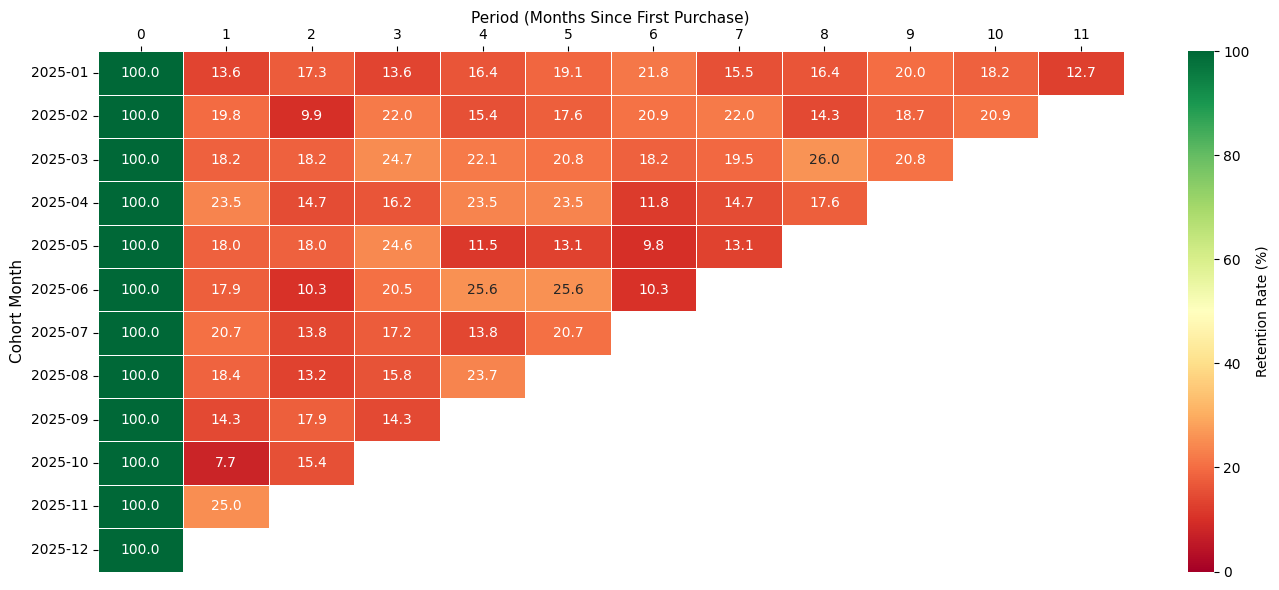

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cohort_pivot_percent,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)

# ax.set_title('Monthly Cohort Retention Heatmap', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

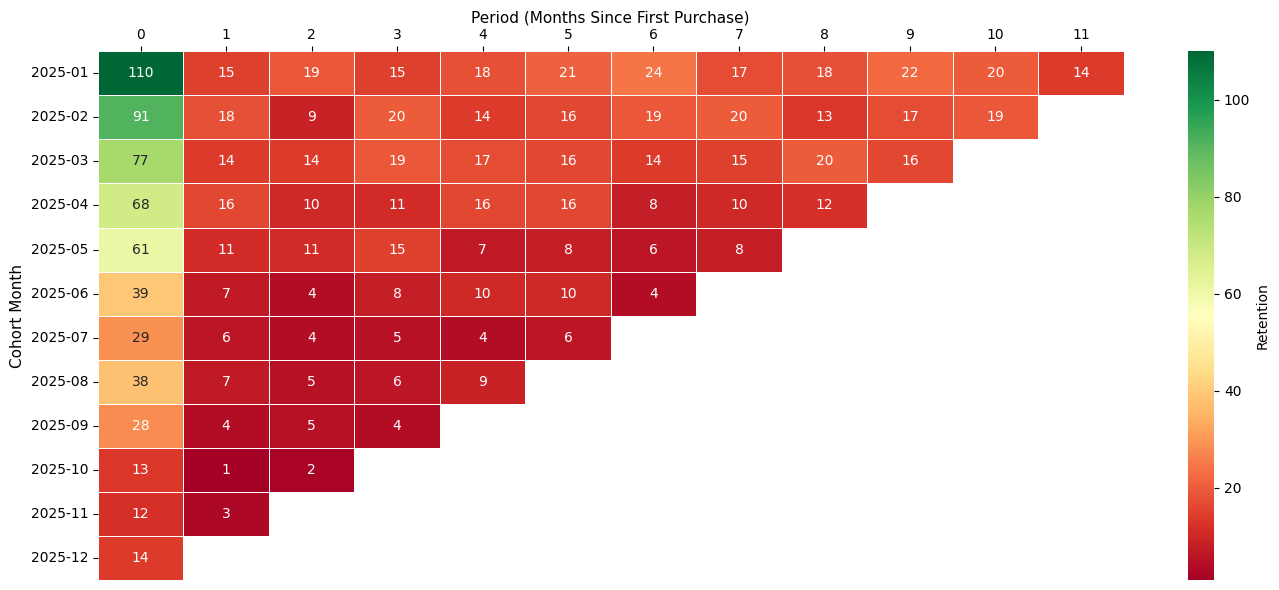

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cohort_pivot_absolute,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention'}
)

# ax.set_title('Monthly Cohort Retention Heatmap', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

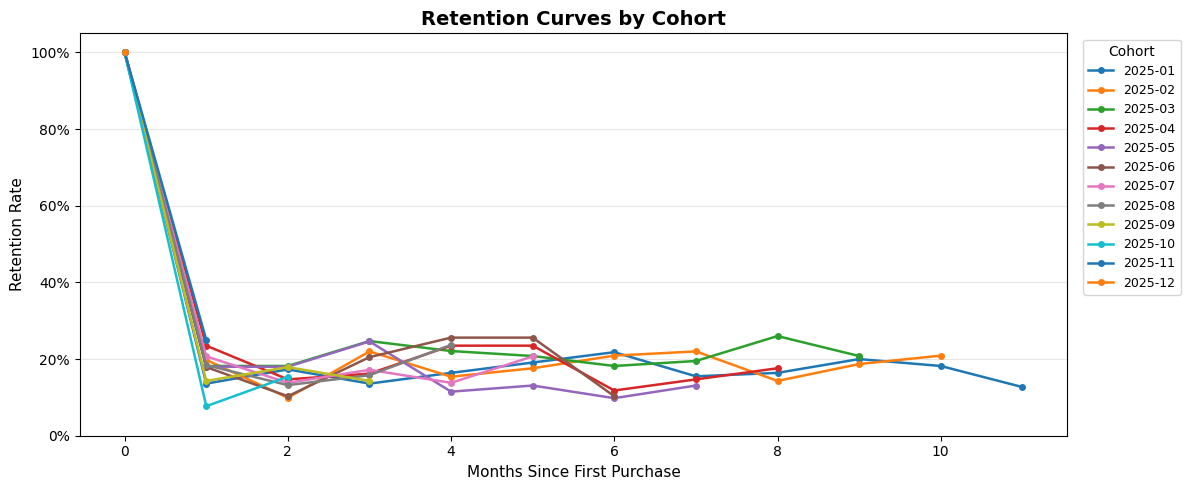

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for cohort in cohort_pivot_percent.index:
    ax.plot(
        cohort_pivot_percent.columns,
        cohort_pivot_percent.loc[cohort],
        marker='o', markersize=4,
        label=cohort, linewidth=1.8
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.set_title('Retention Curves by Cohort', fontsize=14, fontweight='bold')
ax.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cohort_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, which='both')

In [20]:
anomaly_users = df[
    (df['cohort_first_month'].astype(str) == '2025-03') &
    (df['month_diff'] == 2)
]['member_id'].unique()

df[df['member_id'].isin(anomaly_users)].sort_values(['member_id', 'event_timestamp']).tail(20)


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,cohort_first_month,event_month,first_event,month_diff
107008,3533,173,Chromecast,Tablet,Apple,ES,EMEA,2026-04-02,billing,2730,18.07,Success,2025-05-12 12:03:05.701745,2025-03,2025-05,2025-03-22 12:22:02.435317,2
21061,3735,405,Amazon Fire TV,Tablet,Amazon,CA,Americas,2024-08-13,billing,77,0.07,Success,2025-03-30 01:03:20.246927,2025-03,2025-03,2025-03-30 01:03:20.246927,0
1994,3735,249,Amazon Fire TV,Tablet,Apple,CA,Americas,2026-03-24,billing,2306,18.13,Success,2025-05-05 20:35:06.305830,2025-03,2025-05,2025-03-30 01:03:20.246927,2
71290,3735,139,iPad,Game Console,Google,FR,Americas,2025-06-17,billing,2708,11.15,Success,2025-08-13 15:43:13.179911,2025-03,2025-08,2025-03-30 01:03:20.246927,5
12540,3735,184,iPad,Tablet,Amazon,ES,Americas,2025-06-28,billing,2185,10.00,Success,2025-09-01 18:55:12.047111,2025-03,2025-09,2025-03-30 01:03:20.246927,6
23147,3735,185,Amazon Fire TV,Tablet,Samsung,US,EMEA,2025-06-11,billing,3237,2.24,Success,2025-11-19 11:55:59.552298,2025-03,2025-11,2025-03-30 01:03:20.246927,8
97130,3735,285,Chromecast,Tablet,Sony,VN,APAC,2025-02-14,billing,2242,19.91,Success,2025-11-22 18:02:00.967502,2025-03,2025-11,2025-03-30 01:03:20.246927,8
5078,3920,220,Samsung TV,Set Top Box,Amazon,ES,EMEA,2024-06-16,billing,3395,10.48,Success,2025-03-14 09:12:15.274245,2025-03,2025-03,2025-03-14 09:12:15.274245,0
99699,3920,459,iPad,Tablet,Samsung,US,EMEA,2026-01-01,billing,2871,3.17,Success,2025-04-29 17:16:56.357333,2025-03,2025-04,2025-03-14 09:12:15.274245,1
102837,3920,184,PS5,Tablet,Samsung,US,APAC,2024-05-24,billing,1964,11.11,Success,2025-05-06 17:42:39.966112,2025-03,2025-05,2025-03-14 09:12:15.274245,2


In [21]:
import datetime

print(type(datetime.datetime.strptime('2025-11-13 11:05:07.692344', '%Y-%m-%d %H:%M:%S.%f')))

<class 'datetime.datetime'>


In [22]:
df[(df['event_month'] <= pd.Period('2025-12', freq='M')) & (df['event_month'] >= pd.Period('2025-01', freq='M'))]


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,cohort_first_month,event_month,first_event,month_diff
1,4507,246,Samsung TV,Set Top Box,Apple,FR,Americas,2025-11-16,billing,2810,8.84,Success,2025-12-07 21:10:42.540974,2024-09,2025-12,2024-09-20 18:14:06.888185,15
2,1860,434,PS5,Tablet,Amazon,VN,APAC,2025-10-12,billing,3128,5.10,Success,2025-05-03 11:52:31.577340,2024-05,2025-05,2024-05-24 18:56:03.977973,12
17,3919,497,iPad,Tablet,Samsung,US,APAC,2026-03-07,billing,2642,16.98,Success,2025-12-09 04:46:57.107798,2024-08,2025-12,2024-08-18 12:42:42.810963,16
23,3391,468,Chromecast,Streaming Stick,Amazon,ES,EMEA,2026-04-06,billing,2250,15.55,Success,2025-06-02 08:28:59.672829,2024-10,2025-06,2024-10-22 19:13:41.668218,8
30,3324,371,Chromecast,Tablet,Amazon,FR,Americas,2024-09-29,billing,3295,4.22,Success,2025-02-21 13:03:00.165466,2024-06,2025-02,2024-06-21 03:02:01.409631,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119908,2725,372,Amazon Fire TV,Set Top Box,Samsung,DE,Americas,2024-09-05,billing,1956,14.33,Success,2025-09-28 05:31:14.585341,2024-04,2025-09,2024-04-29 10:51:30.961681,17
119914,4249,331,Chromecast,Set Top Box,Google,CA,Americas,2025-03-22,billing,1348,17.01,Success,2025-10-10 12:33:11.771723,2024-07,2025-10,2024-07-28 05:51:51.284094,15
119952,1887,334,PS5,Tablet,Amazon,VN,Americas,2025-01-04,billing,3004,18.78,Success,2025-12-16 09:45:27.913679,2024-10,2025-12,2024-10-05 05:52:34.413394,14
119958,1964,234,iPad,Streaming Stick,Apple,VN,EMEA,2025-05-02,billing,1618,11.30,Success,2025-08-22 22:20:30.414244,2024-06,2025-08,2024-06-16 16:58:34.047630,14
